In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




In [2]:
data = {
    "customer_id": [101,102,103,104,105,106,107,108],
    "age": [19,35,26,45,29,50,23,36],
    "gender": ["Male","Female","Female","Male","Male","Female","Male","Female"],
    "annual_income": [15000,55000,35000,75000,40000,90000,20000,60000],
    "spending_score": [39,81,6,77,40,95,15,60],
    "membership_years": [1,3,2,5,1,6,1,4]
}

In [4]:
df= pd.DataFrame(data)
df

,customer_id,age,gender,annual_income,spending_score,membership_years
0,101,19,Male,15000,39,1
1,102,35,Female,55000,81,3
2,103,26,Female,35000,6,2
3,104,45,Male,75000,77,5
4,105,29,Male,40000,40,1
5,106,50,Female,90000,95,6
6,107,23,Male,20000,15,1
7,108,36,Female,60000,60,4


In [5]:
df.shape

(8, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customer_id       8 non-null      int64 
 1   age               8 non-null      int64 
 2   gender            8 non-null      object
 3   annual_income     8 non-null      int64 
 4   spending_score    8 non-null      int64 
 5   membership_years  8 non-null      int64 
dtypes: int64(5), object(1)
memory usage: 516.0+ bytes


In [7]:
df.isnull()

,customer_id,age,gender,annual_income,spending_score,membership_years
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
5,False,False,False,False,False,False
6,False,False,False,False,False,False
7,False,False,False,False,False,False


In [8]:
df.duplicated()

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
dtype: bool

In [9]:
df.describe()

,customer_id,age,annual_income,spending_score,membership_years
count,8.00000,8.000000,8.000000,8.000000,8.00000
mean,104.50000,32.875000,48750.000000,51.625000,2.87500
std,2.44949,10.736287,26152.028056,32.017573,1.95941
min,101.00000,19.000000,15000.000000,6.000000,1.00000
25%,102.75000,25.250000,31250.000000,33.000000,1.00000
50%,104.50000,32.000000,47500.000000,50.000000,2.50000
75%,106.25000,38.250000,63750.000000,78.000000,4.25000
max,108.00000,50.000000,90000.000000,95.000000,6.00000


In [10]:
df.columns


Index(['customer_id', 'age', 'gender', 'annual_income', 'spending_score',
       'membership_years'],
      dtype='object')

<Axes: xlabel='count', ylabel='gender'>

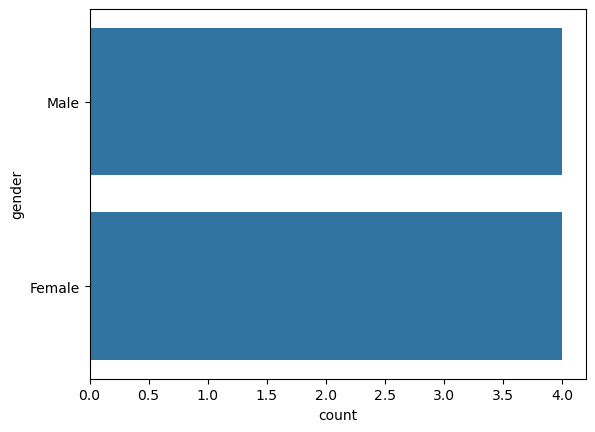

In [13]:
sns.countplot(df['gender'])

<Axes: xlabel='age', ylabel='Count'>

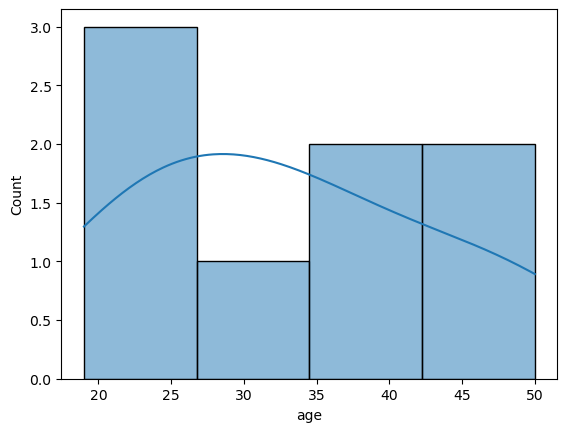

In [16]:
sns.histplot(df['age'],kde=True)

<Axes: xlabel='annual_income', ylabel='Count'>

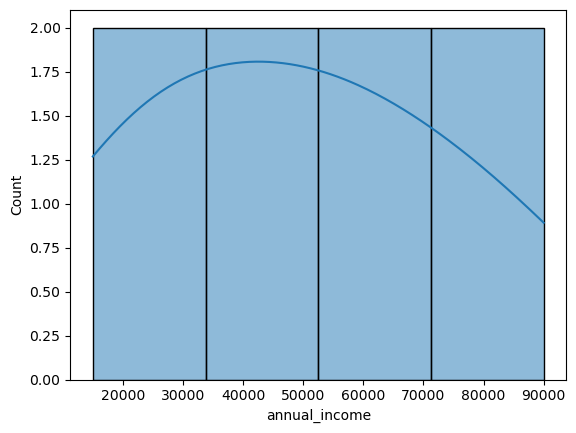

In [18]:
sns.histplot(df['annual_income'],kde=True)

<Axes: xlabel='spending_score', ylabel='Count'>

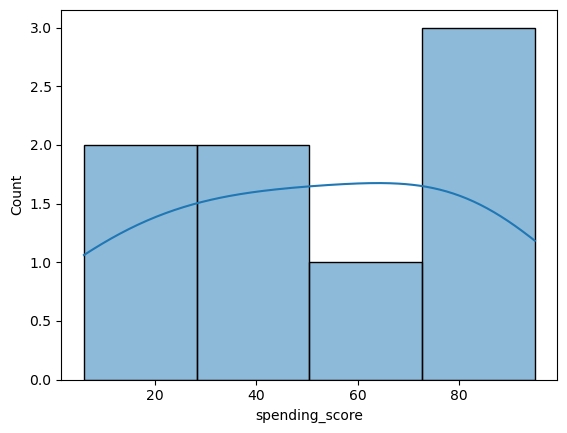

In [19]:
sns.histplot(df['spending_score'],kde=True)

In [30]:
df['age_group']=pd.cut(
    df['age'],
    bins=[0,25,40,60], labels=['Young','Adult','Old']
)

df


,customer_id,age,gender,annual_income,spending_score,membership_years,age_group
0,101,19,Male,15000,39,1,Young
1,102,35,Female,55000,81,3,Adult
2,103,26,Female,35000,6,2,Adult
3,104,45,Male,75000,77,5,Old
4,105,29,Male,40000,40,1,Adult
5,106,50,Female,90000,95,6,Old
6,107,23,Male,20000,15,1,Young
7,108,36,Female,60000,60,4,Adult


In [32]:
df['spending_per_income'] = df['spending_score'] / df['annual_income']
df

,customer_id,age,gender,annual_income,spending_score,membership_years,age_group,spending_per_income
0,101,19,Male,15000,39,1,Young,0.002600
1,102,35,Female,55000,81,3,Adult,0.001473
2,103,26,Female,35000,6,2,Adult,0.000171
3,104,45,Male,75000,77,5,Old,0.001027
4,105,29,Male,40000,40,1,Adult,0.001000
5,106,50,Female,90000,95,6,Old,0.001056
6,107,23,Male,20000,15,1,Young,0.000750
7,108,36,Female,60000,60,4,Adult,0.001000


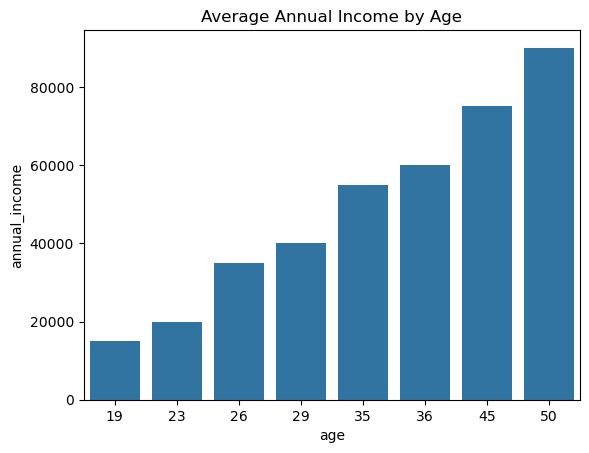

In [35]:
sns.barplot(x='age', y='annual_income', data=df.groupby('age', as_index=False)['annual_income'].mean())
plt.title('Average Annual Income by Age')
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_36200\1188219263.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['membership_years'].mean().plot(kind='bar')


<Axes: xlabel='age_group'>

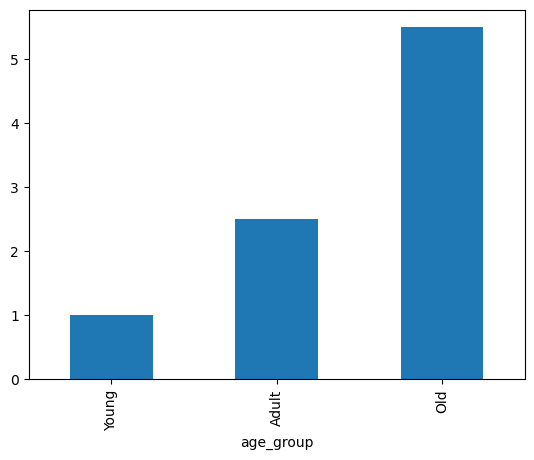

In [43]:
df.groupby('age_group')['membership_years'].mean().plot(kind='bar')

C:\Users\user\AppData\Local\Temp\ipykernel_36200\2998220669.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['spending_per_income'].mean().plot(kind='bar', color='skyblue')


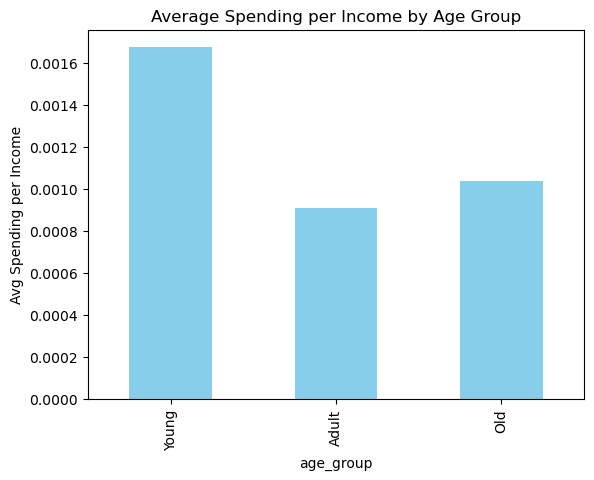

In [45]:
df.groupby('age_group')['spending_per_income'].mean().plot(kind='bar', color='skyblue')
plt.ylabel('Avg Spending per Income')
plt.title('Average Spending per Income by Age Group')
plt.show()

In [46]:
df.groupby('age_group')[['spending_score','annual_income','spending_per_income']].mean()

C:\Users\user\AppData\Local\Temp\ipykernel_36200\2821186863.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')[['spending_score','annual_income','spending_per_income']].mean()


,spending_score,annual_income,spending_per_income
age_group,,,
Young,27.00,17500.0,0.001675
Adult,46.75,47500.0,0.000911
Old,86.00,82500.0,0.001041


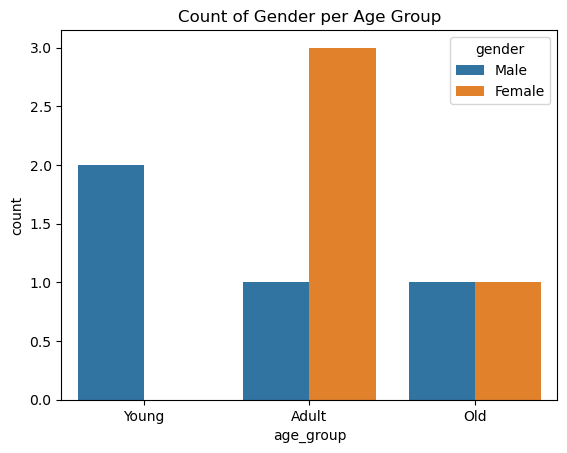

In [51]:

sns.countplot(x='age_group', hue='gender', data=df)
plt.title('Count of Gender per Age Group')
plt.show()